Diagnostic Wisconsin Breast Cancer Database
https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

import gc
import sys
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/breast-cancer")
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.tool import (
    evaluate_model
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load Breast Cancer Wisconsin Dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target                  # 0 = malignant, 1 = benign
feature_names = X.columns
label_names = {0: "malignant", 1: "benign"}
print(feature_names)

# Train/Test Split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Preprocess Data
scaler = StandardScaler(with_mean=True, with_std=True)
X_train = scaler.fit_transform(X_train)   # fit on train
X_test  = scaler.transform(X_test)        # transform test with train stats

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


In [3]:
model_list = [
    ("SVM Linear", GridSearchCV(
        SVC(kernel="linear", probability=True, random_state=42),
        param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
        cv=5,
        scoring="accuracy")),
    ("SVM RBF", GridSearchCV(
        SVC(kernel="rbf", probability=True, random_state=42),
        param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
        cv=5,
        scoring="accuracy")),
    ("Logistic Regression", LogisticRegression(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42)),
]

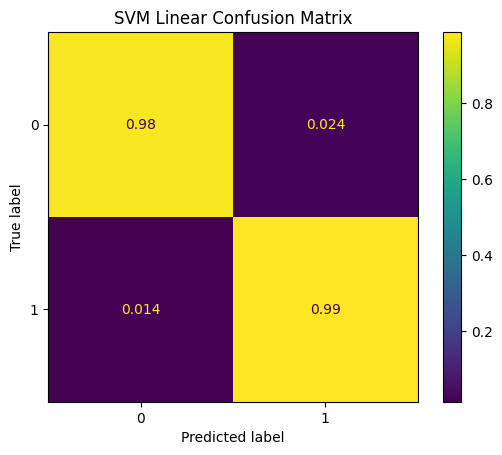

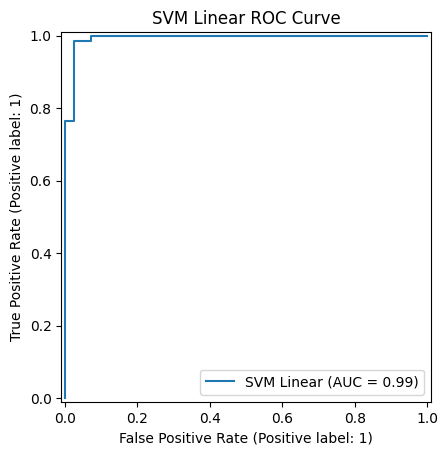

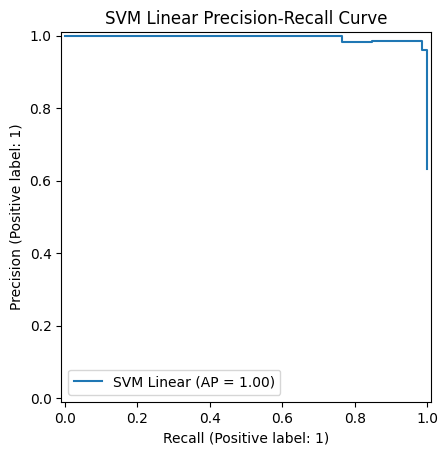

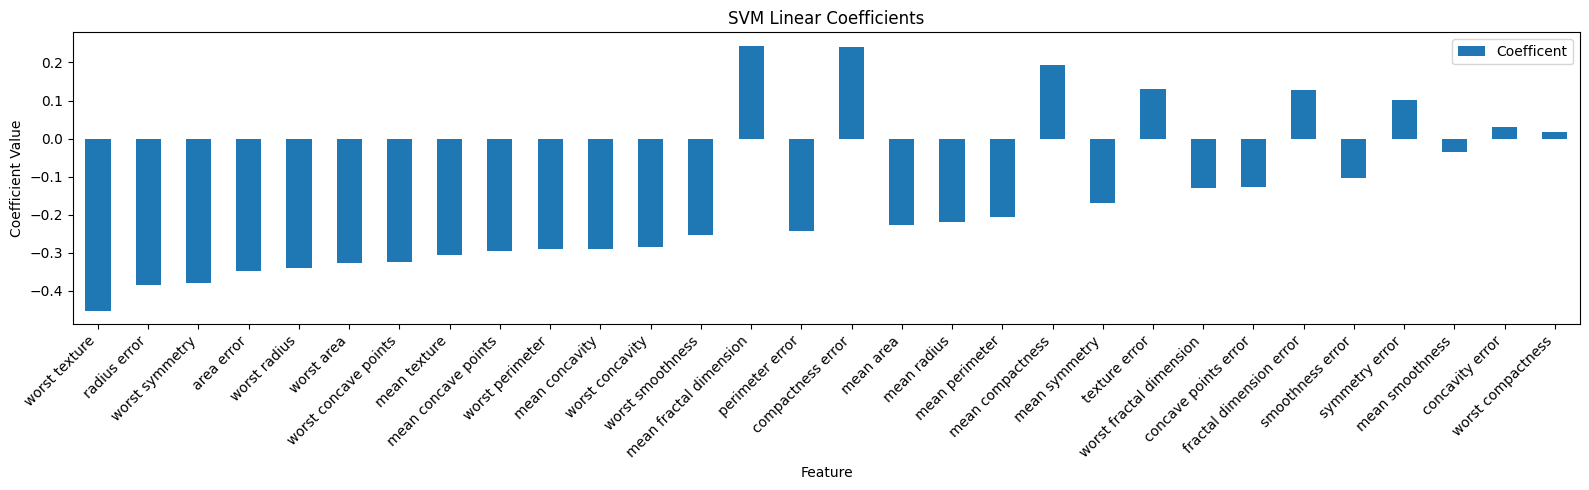

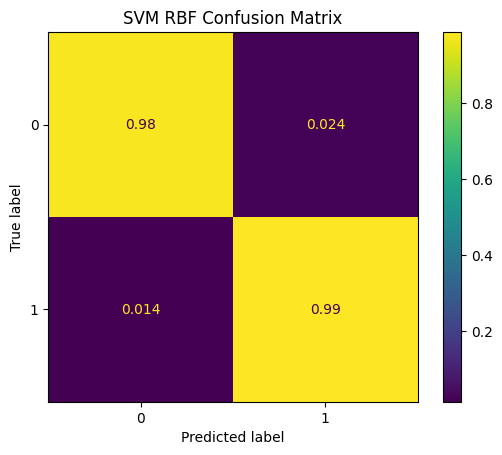

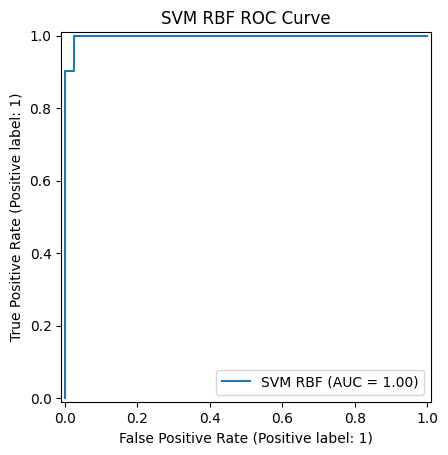

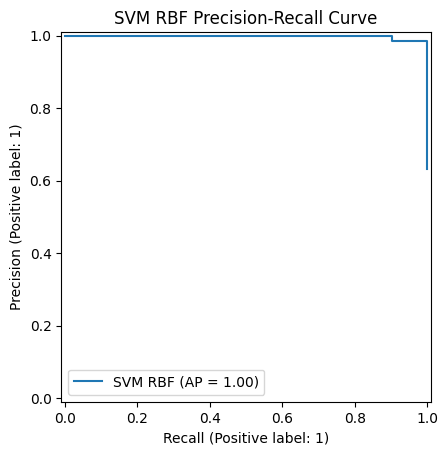

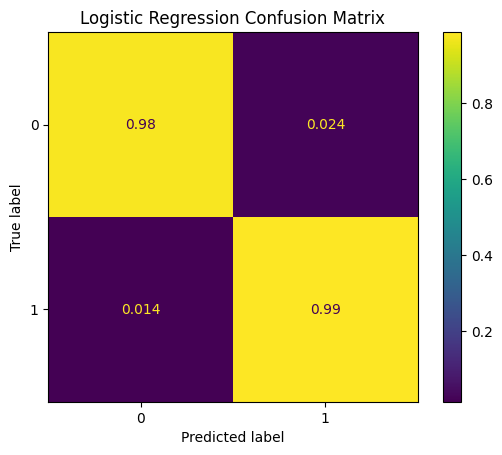

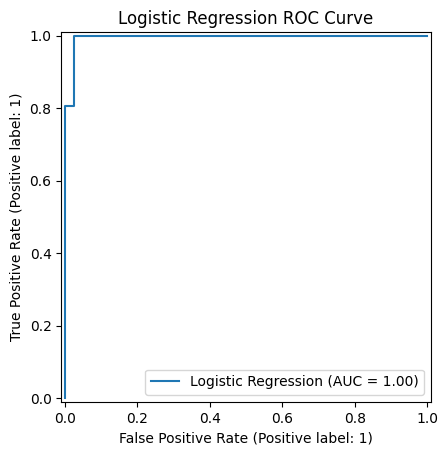

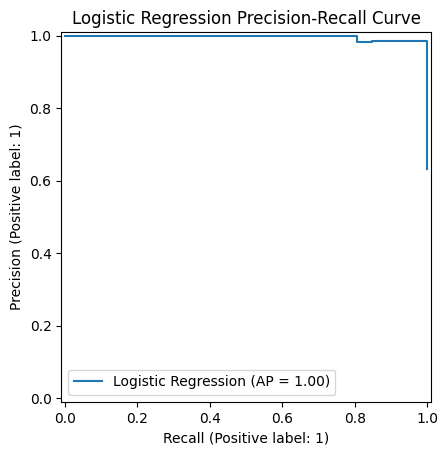

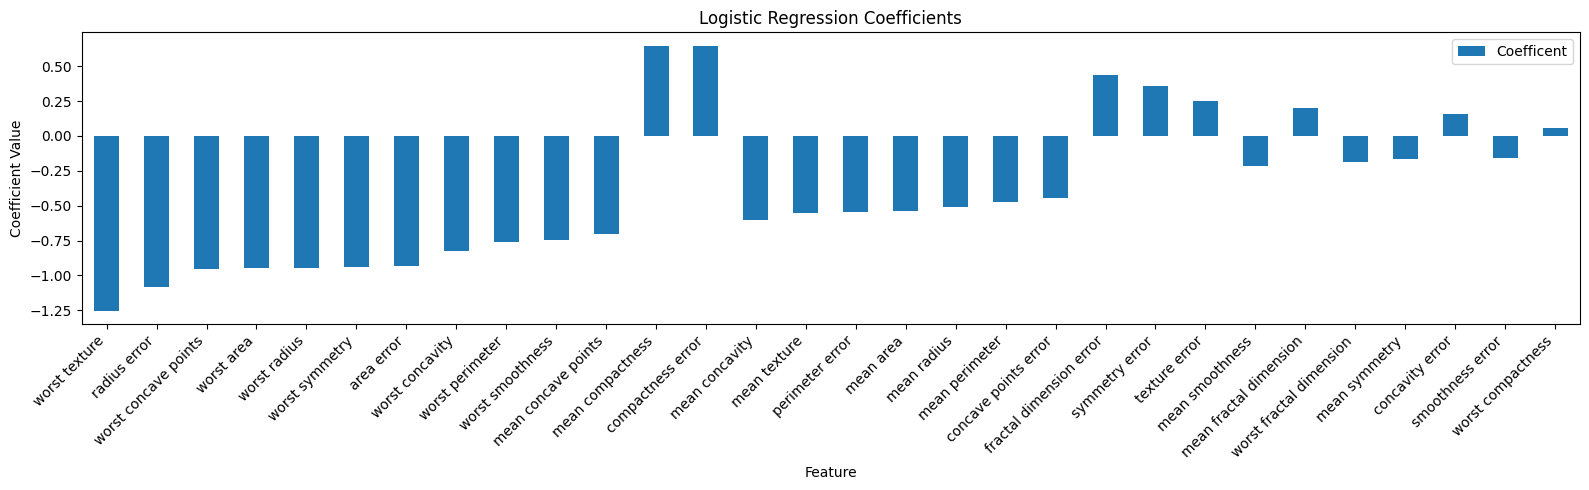

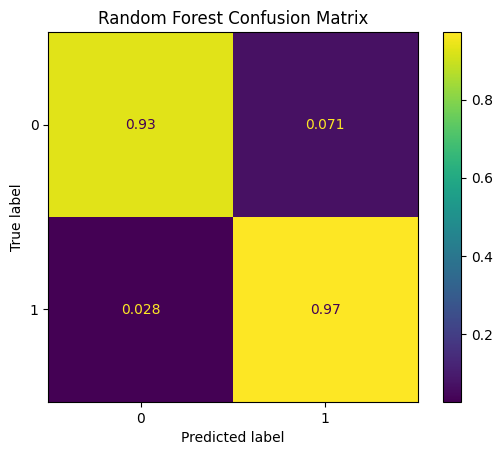

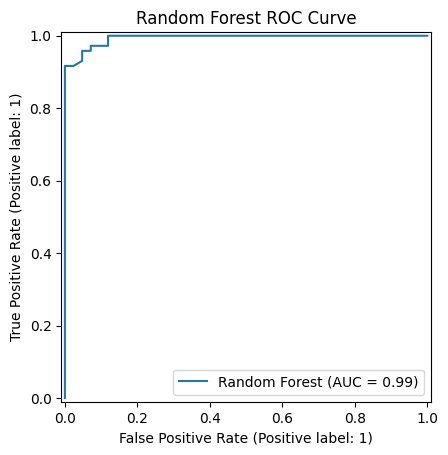

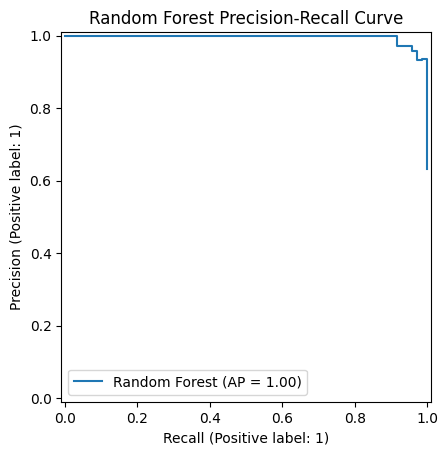

In [4]:
results_df = evaluate_model(model_list, X_train, X_test, y_train, y_test, feature_names, RESULTS_DIR / "results.csv")

In [5]:
results_df

,model,train_acc,test_acc,train_roc_auc,test_roc_auc,train_ap,test_ap
0,SVM Linear_{'C': 0.1},0.984615,0.982456,0.996842,0.993717,0.997708,0.995981
1,"SVM RBF_{'C': 10, 'gamma': 0.01}",0.986813,0.982456,0.998163,0.997685,0.998769,0.998610
2,Logistic Regression,0.989011,0.982456,0.997482,0.995370,0.998281,0.997065
3,Random Forest,1.000000,0.956140,1.000000,0.993882,1.000000,0.996423
